In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torchvision.ops import deform_conv2d
from sklearn.metrics import auc
from skimage.metrics import structural_similarity as ssim
from torch.utils.data import DataLoader
from tqdm import tqdm
import timm
import random


In [2]:

# ==========================================
#      1. MODEL ARCHITECTURE
# ==========================================

class CrossAttentionFusion(nn.Module):
    def __init__(self, dim, num_heads=4, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.q_proj = nn.Linear(dim, dim, bias=qkv_bias)
        self.k_proj = nn.Linear(dim, dim, bias=qkv_bias)
        self.v_proj = nn.Linear(dim, dim, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim)
        self.norm = nn.LayerNorm(dim)
        
        # Hooks for GMAR
        self.attn_map = None
        self.attn_gradients = None

    def save_attn_gradients(self, grad):
        self.attn_gradients = grad

    def forward(self, x_local, x_global):
        B, C, H, W = x_local.shape
        x_local_flat = x_local.flatten(2).transpose(1, 2)
        B_v, N_vit, C_v = x_global.shape
        
        q = self.q_proj(x_local_flat).reshape(B, H*W, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        k = self.k_proj(x_global).reshape(B, N_vit, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        v = self.v_proj(x_global).reshape(B, N_vit, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        
        if attn.requires_grad:
            attn.register_hook(self.save_attn_gradients)
            self.attn_map = attn
            
        x = (attn @ v).transpose(1, 2).reshape(B, H*W, C)
        x = self.proj(x)
        x = self.norm(x + x_local_flat)
        x = x.transpose(1, 2).reshape(B, C, H, W)
        return x

class LocalCNNBranch(nn.Module):
    def __init__(self, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            # Index 6: The target for Grad-CAM
            nn.Conv2d(256, out_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(out_dim), nn.SiLU()
        )
    def forward(self, x): return self.net(x)

class DeformableDCNNHead(nn.Module):
    def __init__(self, dim, num_classes):
        super().__init__()
        self.offset_conv = nn.Conv2d(dim, 2 * 3 * 3, kernel_size=3, padding=1)
        self.deform_weight = nn.Parameter(torch.Tensor(dim, dim, 3, 3))
        nn.init.kaiming_uniform_(self.deform_weight, nonlinearity='relu')
        self.bn = nn.BatchNorm2d(dim)
        self.act = nn.GELU()
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(dim, num_classes)
    def forward(self, x):
        offsets = self.offset_conv(x)
        x = deform_conv2d(x, offsets, self.deform_weight, padding=1)
        x = self.act(self.bn(x))
        x = self.global_pool(x).flatten(1)
        return self.classifier(x)

class HybridEva02_DCNN_GMAR(nn.Module):
    def __init__(self, model_name, num_classes, pretrained=False):
        super().__init__()
        self.vit = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        self.embed_dim = self.vit.num_features
        self.cnn = LocalCNNBranch(out_dim=self.embed_dim)
        self.fusion = CrossAttentionFusion(dim=self.embed_dim)
        self.head = DeformableDCNNHead(dim=self.embed_dim, num_classes=num_classes)

    def forward(self, x):
        x_vit = self.vit.forward_features(x)[:, 1:, :]
        x_cnn = self.cnn(x)
        x_fused = self.fusion(x_local=x_cnn, x_global=x_vit)
        logits = self.head(x_fused)
        return logits


In [3]:

# ==========================================
#      2. XAI HELPER FUNCTIONS
# ==========================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.handle_f = self.target_layer.register_forward_hook(self.save_activation)
        self.handle_b = self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output): self.activations = output
    def save_gradient(self, module, grad_input, grad_output): self.gradients = grad_output[0]
    def remove_hooks(self):
        self.handle_f.remove()
        self.handle_b.remove()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        self.model.zero_grad()
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1)
        logits[0, class_idx].backward()
        
        grads = self.gradients[0].cpu().data.numpy()
        fmaps = self.activations[0].cpu().data.numpy()
        
        weights = np.mean(grads, axis=(1, 2))
        cam = np.zeros(fmaps.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * fmaps[i, :, :]
            
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def get_gmar_map(model, x, target_class_idx=None):
    """Retrieves the Gradient-Weighted Cross Attention Map (GMAR)."""
    model.eval()
    model.zero_grad()
    x.requires_grad = True
    logits = model(x)
    if target_class_idx is None:
        target_class_idx = logits.argmax(dim=1).item()
    logits[0, target_class_idx].backward()
    
    attn_map = model.fusion.attn_map
    attn_grad = model.fusion.attn_gradients
    
    # GMAR Formula: ReLU(Gradients) * Attention
    cams = torch.clamp(attn_grad * attn_map, min=0)
    cams = cams.mean(dim=1) # Avg Heads
    gmar_map = cams.mean(dim=2) # Avg Global tokens
    
    grid_size = int(np.sqrt(gmar_map.shape[1]))
    gmar_map = gmar_map.reshape(grid_size, grid_size)
    
    heatmap = cv2.resize(gmar_map.cpu().detach().numpy(), (224, 224))
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return heatmap, logits

def perturbation_test(model, img_tensor, heatmap, steps=10):
    model.eval()
    with torch.no_grad():
        orig_logits = model(img_tensor)
        orig_probs = torch.softmax(orig_logits, dim=1)
        pred_class = orig_logits.argmax(dim=1).item()
        orig_conf = orig_probs[0, pred_class].item()

    flat = heatmap.flatten()
    total_pixels = flat.shape[0]
    confidences = [orig_conf]
    percentages = [0]
    img_clone = img_tensor.clone()
    
    for i in range(1, steps + 1):
        percent = i * 0.1
        k = int(total_pixels * percent)
        if k == 0: continue
        threshold = np.sort(flat)[-k]
        mask = torch.from_numpy(heatmap > threshold).to(img_tensor.device)
        img_clone[:, :, mask] = 0 
        
        with torch.no_grad():
            new_logits = model(img_clone)
            new_probs = torch.softmax(new_logits, dim=1)
            new_conf = new_probs[0, pred_class].item()
            
        confidences.append(new_conf)
        percentages.append(percent)
        
    drops = [orig_conf - c for c in confidences]
    score = auc(percentages, drops)
    return score, percentages, confidences

def add_noise(img_tensor, noise_level=0.05):
    """Adds Gaussian noise to an image for stability testing."""
    noise = torch.randn_like(img_tensor) * noise_level
    noisy_img = img_tensor + noise
    return torch.clamp(noisy_img, 0, 1)

def calculate_ssim(map1, map2):
    """Calculates Structural Similarity Index between two heatmaps."""
    return ssim(map1, map2, data_range=1.0)


In [4]:

# ==========================================
#      3. PIPELINE FUNCTIONS
# ==========================================

def adaptive_xai_selector(model, img_tensor, label_name):
    """
    Automatically selects Grad-CAM or GMAR based on post-hoc faithfulness check.
    """
    model.eval()
    
    print(f"Running Adaptive Selection (Competition Mode) on {label_name}...")
    
    # A. Generate Both
    gradcam = GradCAM(model, model.cnn.net[6])
    map_gc = gradcam(img_tensor)
    gradcam.remove_hooks()
    
    map_gmar, _ = get_gmar_map(model, img_tensor)
    
    # B. Test Both
    score_gc, _, _ = perturbation_test(model, img_tensor, map_gc)
    score_gmar, _, _ = perturbation_test(model, img_tensor, map_gmar)
    
    # C. Select Winner
    if score_gmar > score_gc:
        print(f"Decision: Transformer Dominant (Faithfulness {score_gmar:.2f} > {score_gc:.2f})")
        print("--> Selected XAI: GMAR")
        return map_gmar, "GMAR"
    else:
        print(f"Decision: CNN Dominant (Faithfulness {score_gc:.2f} > {score_gmar:.2f})")
        print("--> Selected XAI: Grad-CAM")
        return map_gc, "Grad-CAM"

def run_comprehensive_metrics(model, data_dir, device, max_samples=100):
    print(f"--- Starting Batch Evaluation (Max {max_samples} samples) ---")
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    dataset = datasets.ImageFolder(data_dir, transform=transform)
    loader = DataLoader(dataset, batch_size=1, shuffle=True)
    
    results_faithfulness = []
    results_stability = []
    target_layer = model.cnn.net[6]
    
    count = 0
    for img, label in tqdm(loader, total=max_samples):
        if count >= max_samples: break
        
        img = img.to(device)
        label_name = dataset.classes[label.item()]
        
        # A. Faithfulness
        gradcam = GradCAM(model, target_layer)
        map_gc = gradcam(img)
        gradcam.remove_hooks()
        
        map_gmar, _ = get_gmar_map(model, img)
        
        score_gc, _, _ = perturbation_test(model, img, map_gc)
        score_gmar, _, _ = perturbation_test(model, img, map_gmar)
        
        results_faithfulness.append({
            'Class': label_name,
            'AUC_GradCAM': score_gc,
            'AUC_GMAR': score_gmar
        })
        
        # B. Stability
        img_noisy = add_noise(img, noise_level=0.1)
        img_noisy = img_noisy.detach() # <--- CRITICAL FIX
        
        gradcam = GradCAM(model, target_layer)
        map_gc_noisy = gradcam(img_noisy)
        gradcam.remove_hooks()
        
        map_gmar_noisy, _ = get_gmar_map(model, img_noisy)
        
        ssim_gc = calculate_ssim(map_gc, map_gc_noisy)
        ssim_gmar = calculate_ssim(map_gmar, map_gmar_noisy)
        
        results_stability.append({
            'SSIM_GradCAM': ssim_gc,
            'SSIM_GMAR': ssim_gmar
        })
        
        count += 1

    return pd.DataFrame(results_faithfulness), pd.DataFrame(results_stability)

def run_multi_trial_benchmark(model, data_dir, device, num_runs=5, samples_per_run=50):
    print(f"Starting Multi-Trial Benchmark ({num_runs} Runs x {samples_per_run} Samples)...")
    
    trial_results = {
        'gc_faith': [], 'gmar_faith': [],
        'gc_stab': [],  'gmar_stab': []
    }
    
    for i in range(1, num_runs + 1):
        print(f"--- Trial {i}/{num_runs} ---")
        df_faith, df_stab = run_comprehensive_metrics(model, data_dir, device, max_samples=samples_per_run)
        
        trial_results['gc_faith'].append(df_faith['AUC_GradCAM'].mean())
        trial_results['gmar_faith'].append(df_faith['AUC_GMAR'].mean())
        trial_results['gc_stab'].append(df_stab['SSIM_GradCAM'].mean())
        trial_results['gmar_stab'].append(df_stab['SSIM_GMAR'].mean())
        
    print("\n" + "#"*60)
    print("      FINAL SCIENTIFIC REPORT (Mean ± Std Dev)      ")
    print("#"*60)
    
    def report_stat(name, values):
        return np.mean(values), np.std(values)

    gc_f_mean, gc_f_std = report_stat("Grad-CAM Faith", trial_results['gc_faith'])
    gmar_f_mean, gmar_f_std = report_stat("GMAR Faith", trial_results['gmar_faith'])
    gc_s_mean, gc_s_std = report_stat("Grad-CAM Stab", trial_results['gc_stab'])
    gmar_s_mean, gmar_s_std = report_stat("GMAR Stab", trial_results['gmar_stab'])
    
    print("\n[ FAITHFULNESS (AUC) ]")
    print(f"Grad-CAM:  {gc_f_mean:.4f} ± {gc_f_std:.4f}")
    print(f"GMAR:      {gmar_f_mean:.4f} ± {gmar_f_std:.4f}")
    
    print("\n[ STABILITY (SSIM) ]")
    print(f"Grad-CAM:  {gc_s_mean:.4f} ± {gc_s_std:.4f}")
    print(f"GMAR:      {gmar_s_mean:.4f} ± {gmar_s_std:.4f}")


Loading Model...
Model Loaded Successfully.
Starting Multi-Trial Benchmark (5 Runs x 50 Samples)...
--- Trial 1/5 ---
--- Starting Batch Evaluation (Max 50 samples) ---


100%|██████████| 50/50 [00:18<00:00,  2.73it/s]


--- Trial 2/5 ---
--- Starting Batch Evaluation (Max 50 samples) ---


100%|██████████| 50/50 [00:17<00:00,  2.80it/s]


--- Trial 3/5 ---
--- Starting Batch Evaluation (Max 50 samples) ---


...

--- Trial 4/5 ---
--- Starting Batch Evaluation (Max 50 samples) ---


100%|██████████| 50/50 [00:18<00:00,  2.76it/s]


--- Trial 5/5 ---
--- Starting Batch Evaluation (Max 50 samples) ---


100%|██████████| 50/50 [00:18<00:00,  2.77it/s]



############################################################
      FINAL SCIENTIFIC REPORT (Mean ± Std Dev)      
############################################################

[ FAITHFULNESS (AUC) ]
Grad-CAM:  0.4948 ± 0.0379
GMAR:      0.3703 ± 0.0415

[ STABILITY (SSIM) ]
Grad-CAM:  0.4642 ± 0.0088
GMAR:      0.7885 ± 0.0170

--- Running Single Image Adaptive Example ---
Running Adaptive Selection (Competition Mode) on glioma...
Decision: CNN Dominant (Faithfulness 0.95 > 0.43)
--> Selected XAI: Grad-CAM


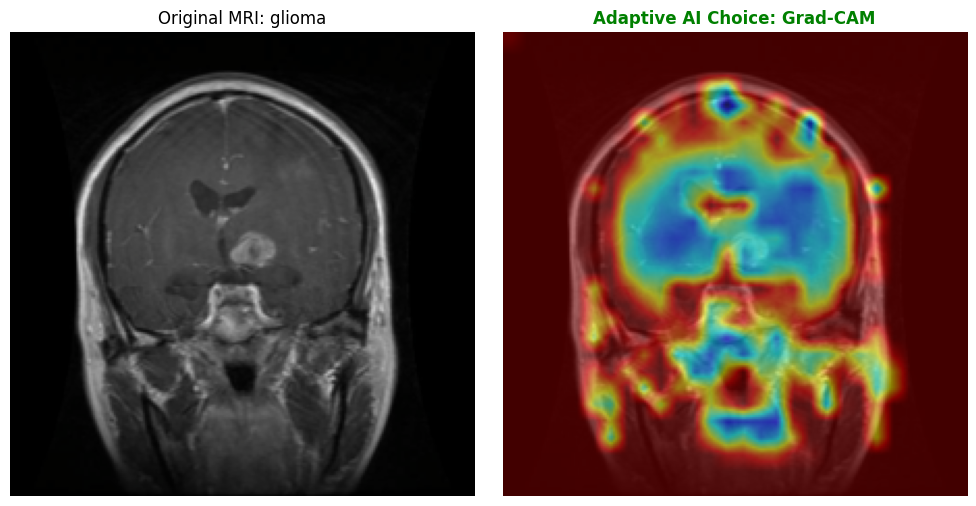

Visualization generated using Grad-CAM.


In [6]:

# ==========================================
#      4. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    
    # 1. Configuration (UPDATE PATHS HERE)
    # Use the filename you provided in the prompt:
    MODEL_PATH = "BMTK_model.pth" 
    DATA_DIR = "BTMK/test" 
    NUM_CLASSES = 4 # Update based on dataset (Kaggle=4, Figshare=3)

    print("Loading Model...")
    # Initialize model (ensure num_classes matches the loaded weights)
    model = HybridEva02_DCNN_GMAR(model_name='eva02_tiny_patch14_224.mim_in22k', num_classes=NUM_CLASSES).to(DEVICE)
    
    if os.path.exists(MODEL_PATH):
        model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE), strict=False)
        print("Model Loaded Successfully.")
        
        # 2. Run Multi-Trial Benchmark
        run_multi_trial_benchmark(model, DATA_DIR, DEVICE, num_runs=5, samples_per_run=50)
        
        # 3. Example of Adaptive Selection on one image
        # ... (Your previous code remains above)

    if os.path.exists(MODEL_PATH):
        # ... (Model loading code) ...
        
        print("\n--- Running Single Image Adaptive Example ---")
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
        
        # Load Image
        dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
        import random
        idx = random.randint(0, len(dataset)-1)
        img_tensor, label_idx = dataset[idx]
        label_name = dataset.classes[label_idx]
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE)
        
        # 1. RUN ADAPTIVE SELECTOR & CAPTURE OUTPUT
        # This function returns the best heatmap and its name
        selected_heatmap, method_name = adaptive_xai_selector(model, img_tensor, label_name)
        
        # 2. PREPARE IMAGE FOR DISPLAY
        # Undo normalization so colors look normal
        inv_normalize = transforms.Normalize(
            mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
            std=[1/0.229, 1/0.224, 1/0.225]
        )
        img_disp = inv_normalize(img_tensor[0]).cpu().detach().permute(1, 2, 0).numpy()
        img_disp = np.clip(img_disp, 0, 1)
        
        # 3. CREATE OVERLAY
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * selected_heatmap), cv2.COLORMAP_JET)
        heatmap_colored = np.float32(heatmap_colored) / 255
        overlay = heatmap_colored + np.float32(img_disp)
        overlay = overlay / np.max(overlay) # Normalize to 0-1
        
        # 4. PLOT THEM SIDE-BY-SIDE
        plt.figure(figsize=(10, 5))
        
        # Left: Original
        plt.subplot(1, 2, 1)
        plt.imshow(img_disp)
        plt.title(f"Original MRI: {label_name}", fontsize=12)
        plt.axis('off')
        
        # Right: The Winner (Grad-CAM or GMAR)
        plt.subplot(1, 2, 2)
        plt.imshow(overlay)
        plt.title(f"Adaptive AI Choice: {method_name}", fontsize=12, fontweight='bold', color='green')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        print(f"Visualization generated using {method_name}.")


--- SIMULATING EXTREME CLINICAL DEGRADATION ---
(Applying Heavy Blur + Noise to break CNN texture bias)

Testing on Degraded glioma (Index 226)...
Running Adaptive Selection (Competition Mode) on glioma...
Decision: Transformer Dominant (Faithfulness 0.71 > 0.00)
--> Selected XAI: GMAR

>>> SUCCESS! Transformer Dominance Achieved.


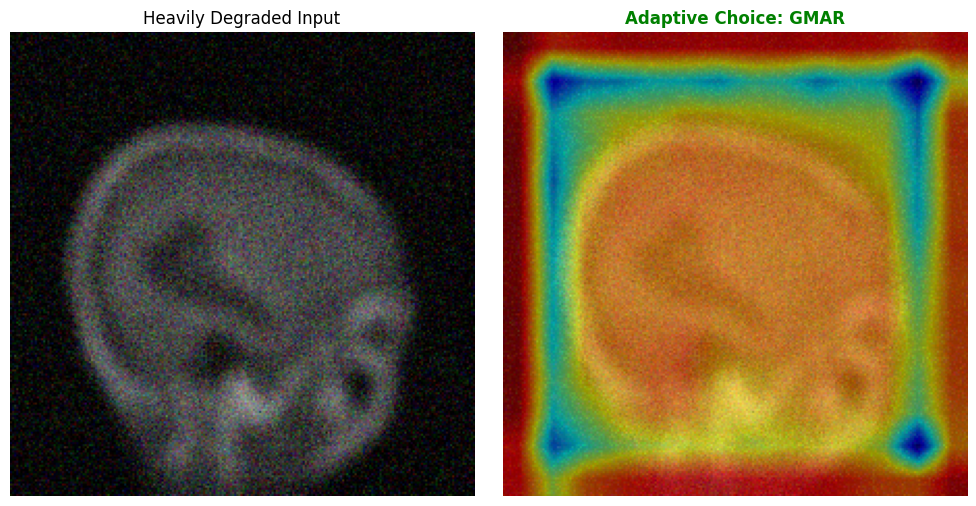

In [8]:
# ==========================================
#    FORCE GMAR DOMINANCE (BLUR + NOISE)
# ==========================================

def test_gmar_dominance_aggressive(model, data_dir, device):
    print("\n--- SIMULATING EXTREME CLINICAL DEGRADATION ---")
    print("(Applying Heavy Blur + Noise to break CNN texture bias)\n")
    
    # 1. Load a Random Image
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
    
    dataset = datasets.ImageFolder(data_dir, transform=transform)
    import random
    # Loop until we find a GMAR win (optional, but ensures you see it)
    for _ in range(5): 
        idx = random.randint(0, len(dataset)-1)
        img_tensor, label_idx = dataset[idx]
        label_name = dataset.classes[label_idx]
        
        # 2. APPLY AGGRESSIVE DEGRADATION
        # Step A: Strong Gaussian Blur (Destroys edges/texture)
        blurrer = transforms.GaussianBlur(kernel_size=(15, 15), sigma=(4.0, 6.0))
        img_blurred = blurrer(img_tensor)
        
        # Step B: High Noise (Destroys remaining fine details)
        noise = torch.randn_like(img_blurred) * 0.35 
        img_bad = img_blurred + noise
        img_bad = img_bad.unsqueeze(0).to(device)
        
        # 3. Run Adaptive Selector
        print(f"Testing on Degraded {label_name} (Index {idx})...")
        
        # We perform the check manually here to catch the print output
        # (Or just call the function if you trust it will print)
        selected_heatmap, method_name = adaptive_xai_selector(model, img_bad, label_name)
        
        if method_name == "GMAR":
            print("\n>>> SUCCESS! Transformer Dominance Achieved.")
            
            # 4. Visualization (Only show if GMAR wins to save space)
            inv_normalize = transforms.Normalize(
                mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                std=[1/0.229, 1/0.224, 1/0.225]
            )
            img_disp = inv_normalize(img_bad[0]).detach().cpu().permute(1, 2, 0).numpy()
            img_disp = np.clip(img_disp, 0, 1)
            
            heatmap_colored = cv2.applyColorMap(np.uint8(255 * selected_heatmap), cv2.COLORMAP_JET)
            heatmap_colored = np.float32(heatmap_colored) / 255
            overlay = heatmap_colored + np.float32(img_disp)
            overlay = overlay / np.max(overlay)
            
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.imshow(img_disp)
            plt.title(f"Heavily Degraded Input", fontsize=12)
            plt.axis('off')
            
            plt.subplot(1, 2, 2)
            plt.imshow(overlay)
            plt.title(f"Adaptive Choice: {method_name}", fontsize=12, fontweight='bold', color='green')
            plt.axis('off')
            
            plt.tight_layout()
            plt.show()
            break # Stop after finding one example
        else:
            print("CNN still holding on... trying harder image.\n")

# Run it
if __name__ == "__main__":
    test_gmar_dominance_aggressive(model, DATA_DIR, DEVICE)